In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/dataset/netflix_titles.csv')

print(f'✅ Dataset loaded! Shape: {df.shape}')
df.head()

✅ Dataset loaded! Shape: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
print('='*55)
print('DATASET INFORMATION')
print('='*55)
print(f'Total Titles: {df.shape[0]}')
print(f'Total Features: {df.shape[1]}')
print()
df.info()

DATASET INFORMATION
Total Titles: 8807
Total Features: 12

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


📊 Missing Values Summary:
            Missing Count  Missing %
director             2634      29.91
country               831       9.44
cast                  825       9.37
date_added             10       0.11
rating                  4       0.05
duration                3       0.03


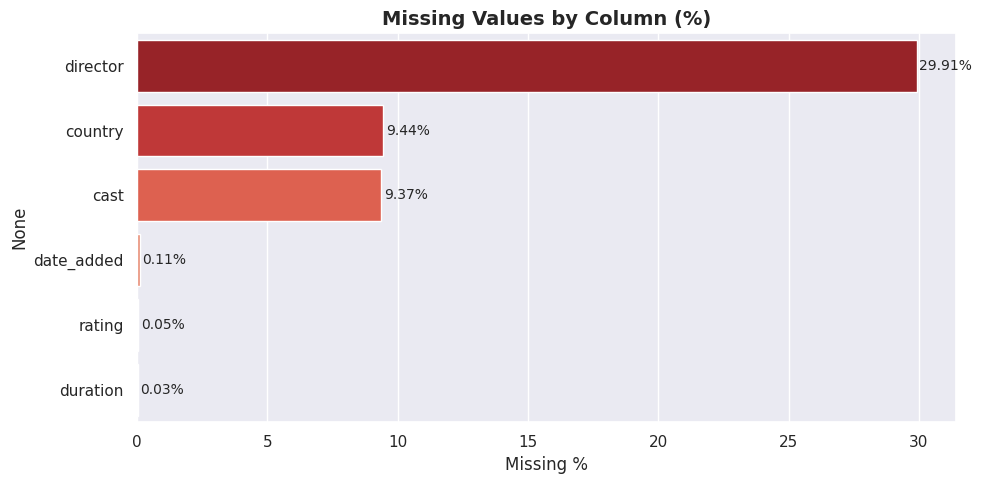

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print('📊 Missing Values Summary:')
print(missing_df[missing_df['Missing Count'] > 0])

fig, ax = plt.subplots(figsize=(10, 5))
missing_plot = missing_df[missing_df['Missing Count'] > 0]
sns.barplot(x=missing_plot['Missing %'], y=missing_plot.index, palette='Reds_r', ax=ax)
ax.set_title('Missing Values by Column (%)', fontsize=14, fontweight='bold')
for i, v in enumerate(missing_plot['Missing %']):
    ax.text(v + 0.1, i, f'{v}%', va='center', fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['rating'].fillna(df['rating'].mode()[0], inplace=True)
df['duration'].fillna('Unknown', inplace=True)
df.dropna(subset=['date_added'], inplace=True)

df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
df['month_name'] = df['date_added'].dt.strftime('%b')
df['duration_int'] = df['duration'].str.extract(r'(\d+)').astype(float)

print(f'✅ Cleaned Dataset Shape: {df.shape}')
print(f'✅ Remaining Missing Values: {df.isnull().sum().sum()}')

✅ Cleaned Dataset Shape: (8797, 16)
✅ Remaining Missing Values: 3


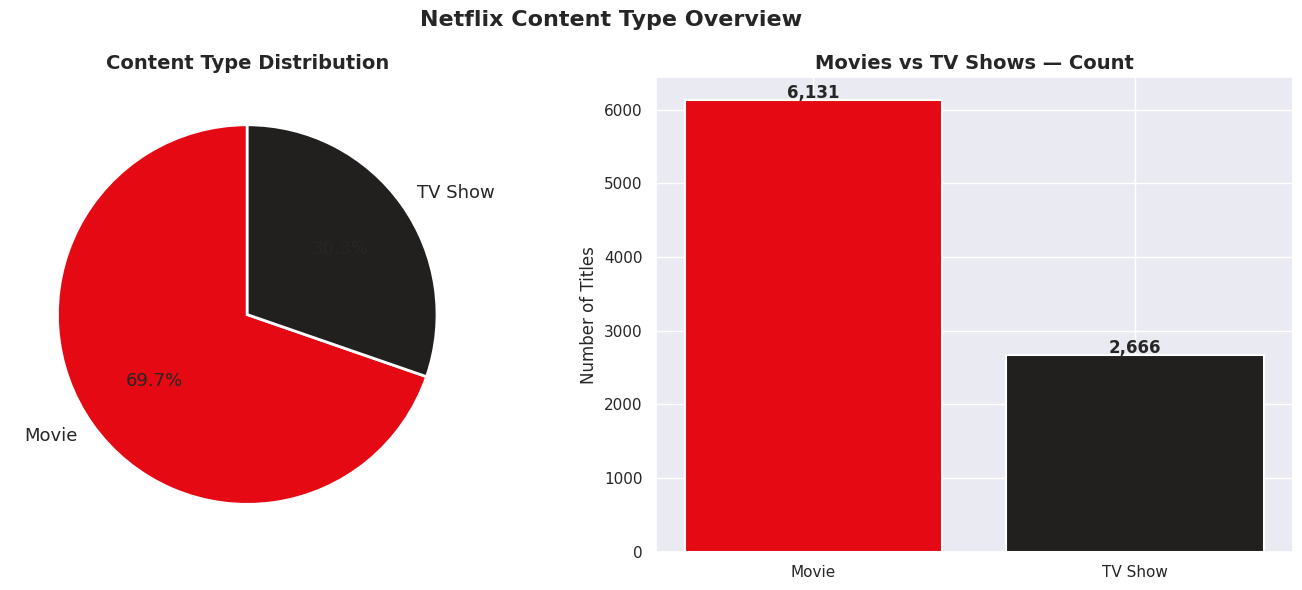

In [ ]:
type_counts = df['type'].value_counts()
colors = ['#E50914', '#221F1F']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 13},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Content Type Distribution', fontsize=14, fontweight='bold')

bars = axes[1].bar(type_counts.index, type_counts.values,
                   color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('Movies vs TV Shows — Count', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Titles')
for bar, val in zip(bars, type_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}', ha='center', fontsize=12, fontweight='bold')

plt.suptitle('Netflix Content Type Overview', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

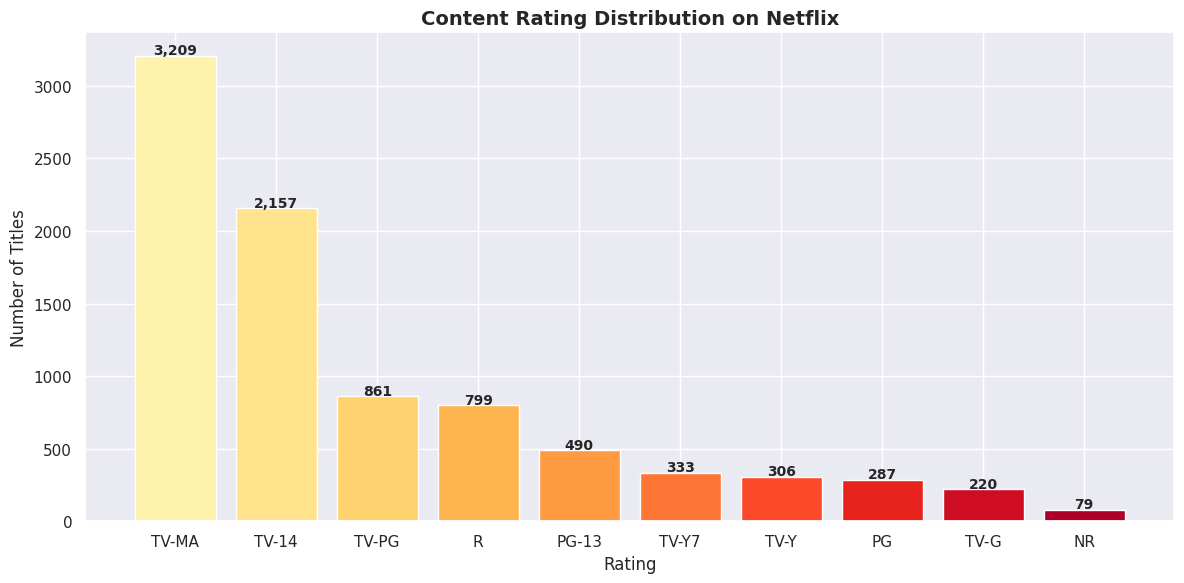

In [ ]:
rating_counts = df['rating'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(rating_counts.index, rating_counts.values,
              color=sns.color_palette('YlOrRd', len(rating_counts)), edgecolor='white')
ax.set_title('Content Rating Distribution on Netflix', fontsize=14, fontweight='bold')
ax.set_xlabel('Rating')
ax.set_ylabel('Number of Titles')
for bar, val in zip(bars, rating_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{val:,}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

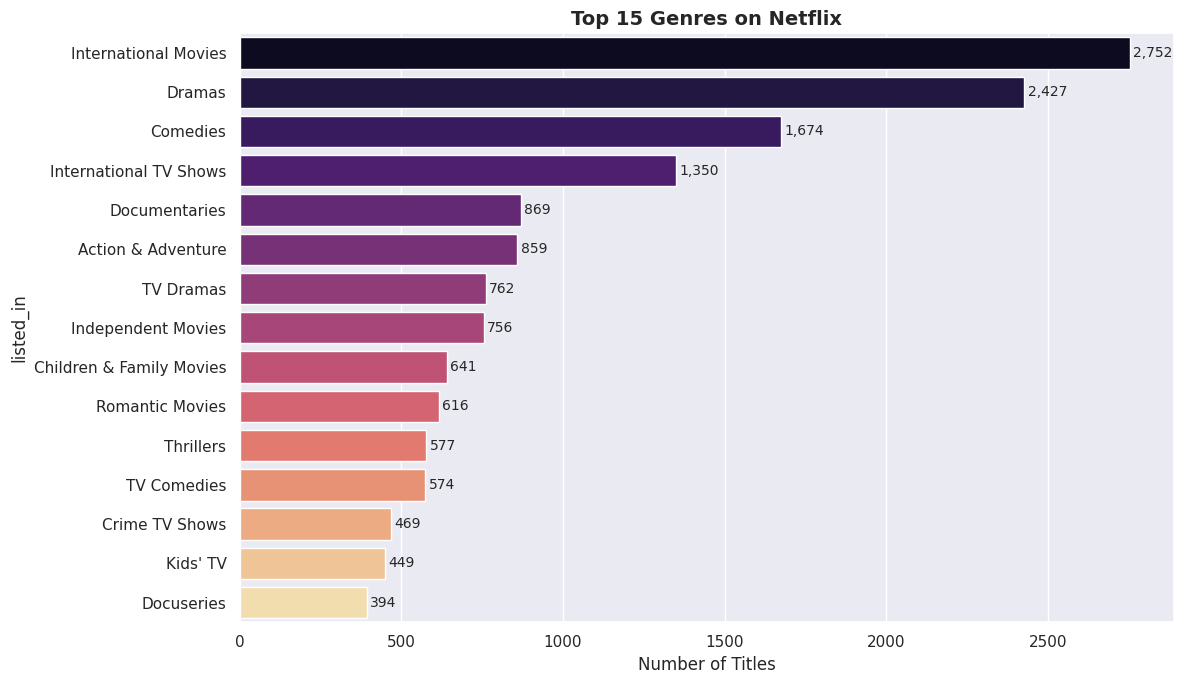

In [ ]:
genres = df['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='magma', ax=ax)
ax.set_title('Top 15 Genres on Netflix', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Titles')
for i, v in enumerate(top_genres.values):
    ax.text(v + 10, i, f'{v:,}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

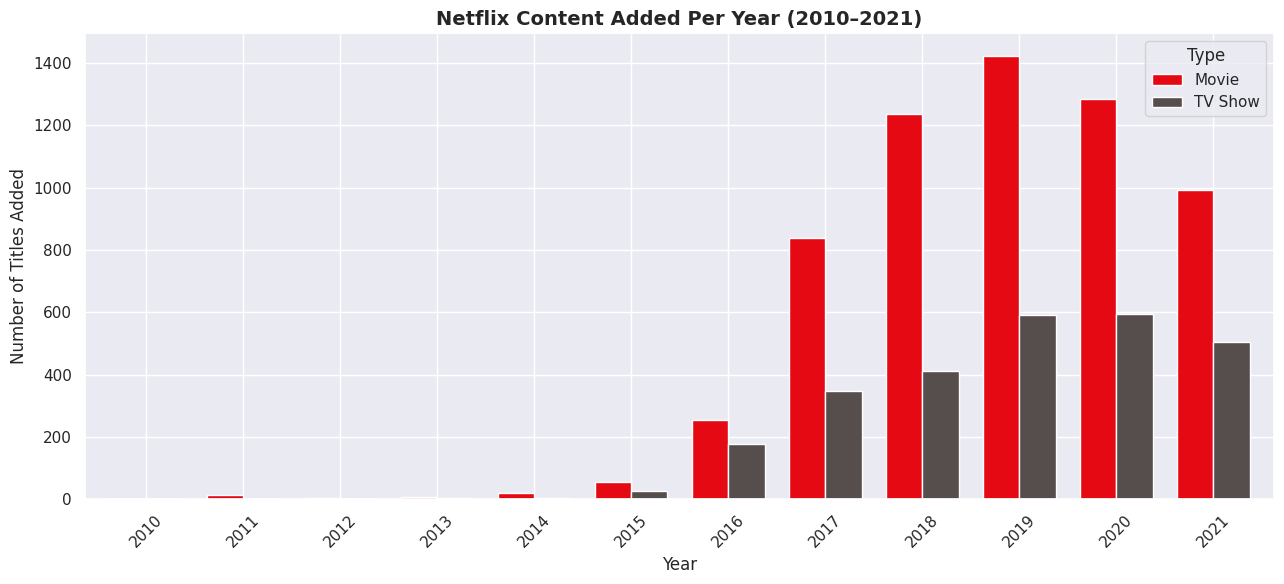

In [ ]:
yearly = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)
yearly = yearly[yearly.index >= 2010]

fig, ax = plt.subplots(figsize=(13, 6))
yearly.plot(kind='bar', ax=ax, color=['#E50914', '#564D4D'],
            edgecolor='white', width=0.75)
ax.set_title('Netflix Content Added Per Year (2010–2021)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Titles Added')
ax.legend(title='Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

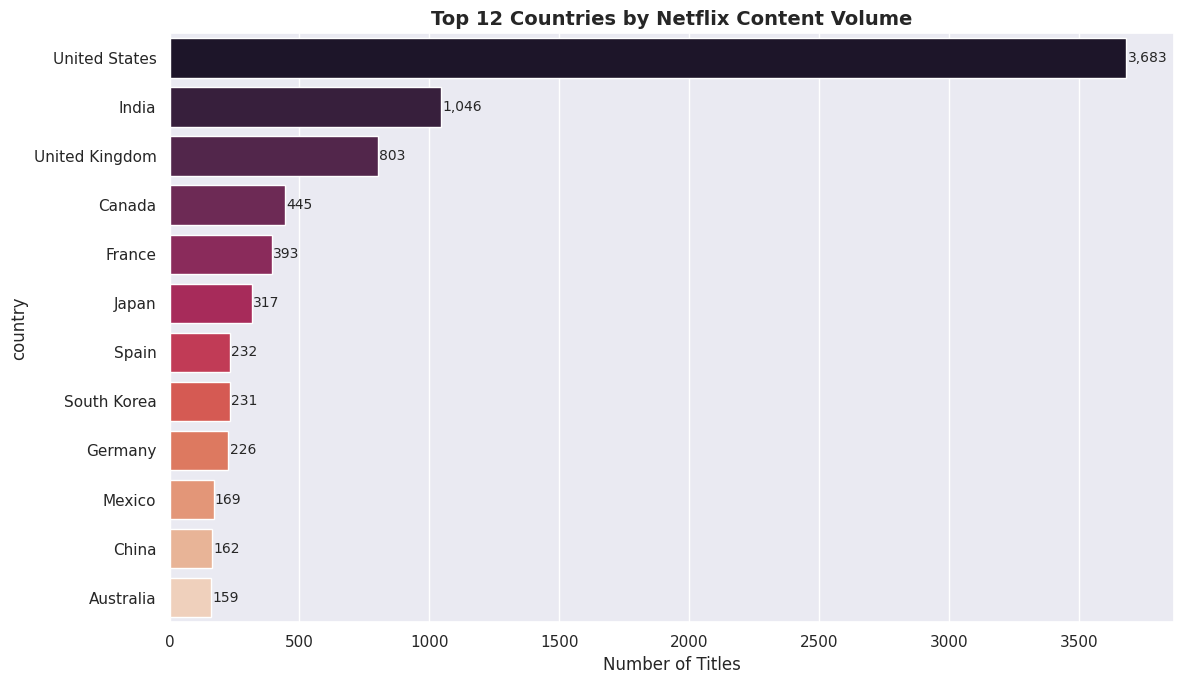

In [ ]:
countries = df[df['country'] != 'Unknown']['country'].str.split(', ').explode()
top_countries = countries.value_counts().head(12)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='rocket', ax=ax)
ax.set_title('Top 12 Countries by Netflix Content Volume', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Titles')
for i, v in enumerate(top_countries.values):
    ax.text(v + 5, i, f'{v:,}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

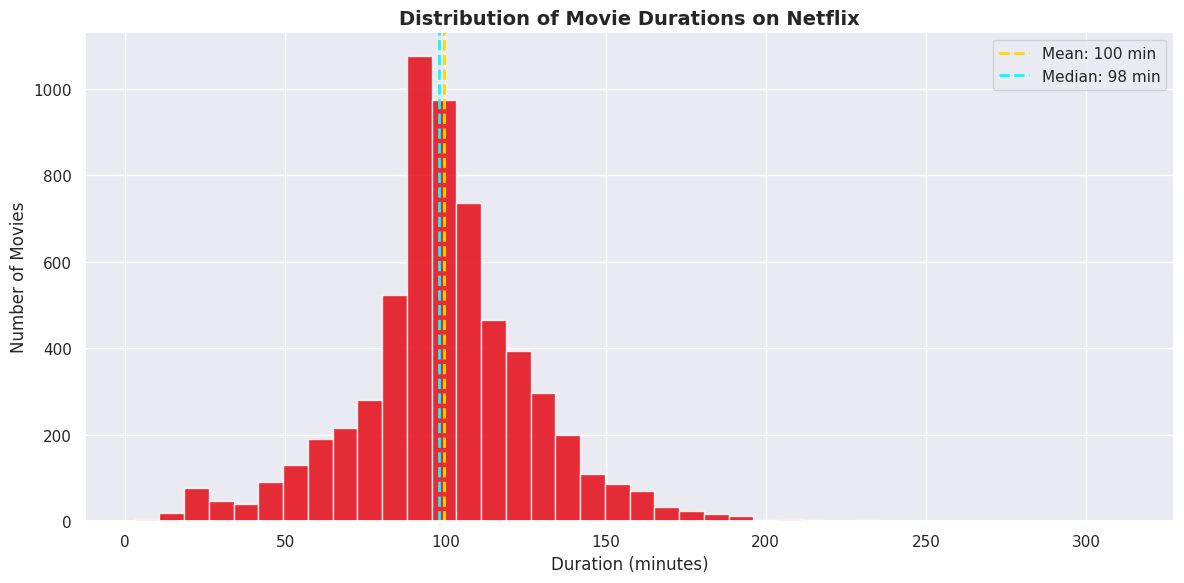


🎬 Average Movie Duration: 100 minutes
🎬 Shortest Movie: 3 minutes
🎬 Longest Movie: 312 minutes


In [ ]:
movies = df[df['type'] == 'Movie']

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(movies['duration_int'].dropna(), bins=40,
        color='#E50914', edgecolor='white', alpha=0.85)
ax.axvline(movies['duration_int'].mean(), color='gold', linewidth=2,
           linestyle='--', label=f"Mean: {movies['duration_int'].mean():.0f} min")
ax.axvline(movies['duration_int'].median(), color='cyan', linewidth=2,
           linestyle='--', label=f"Median: {movies['duration_int'].median():.0f} min")
ax.set_title('Distribution of Movie Durations on Netflix', fontsize=14, fontweight='bold')
ax.set_xlabel('Duration (minutes)')
ax.set_ylabel('Number of Movies')
ax.legend()
plt.tight_layout()
plt.show()

print(f'\n🎬 Average Movie Duration: {movies["duration_int"].mean():.0f} minutes')
print(f'🎬 Shortest Movie: {movies["duration_int"].min():.0f} minutes')
print(f'🎬 Longest Movie: {movies["duration_int"].max():.0f} minutes')

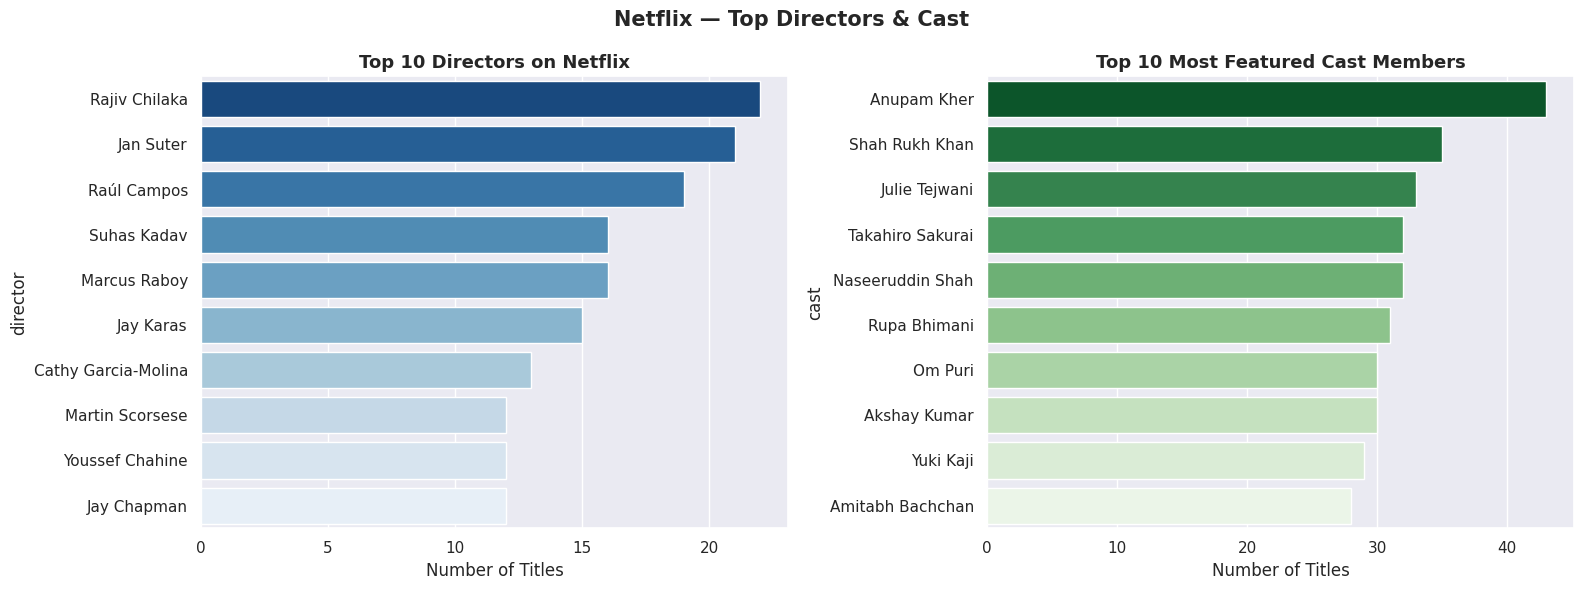

In [ ]:
top_directors = df[df['director'] != 'Unknown']['director']\
    .str.split(', ').explode().value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=top_directors.values, y=top_directors.index, palette='Blues_r', ax=axes[0])
axes[0].set_title('Top 10 Directors on Netflix', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Titles')

top_cast = df[df['cast'] != 'Unknown']['cast']\
    .str.split(', ').explode().value_counts().head(10)
sns.barplot(x=top_cast.values, y=top_cast.index, palette='Greens_r', ax=axes[1])
axes[1].set_title('Top 10 Most Featured Cast Members', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Titles')

plt.suptitle('Netflix — Top Directors & Cast', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print('='*60)
print('         🎬 KEY INSIGHTS — NETFLIX EDA')
print('='*60)
print()
print('📊 CONTENT TYPE')
print(f'  → Movies: {type_counts["Movie"]:,} ({type_counts["Movie"]/len(df)*100:.1f}%)')
print(f'  → TV Shows: {type_counts["TV Show"]:,} ({type_counts["TV Show"]/len(df)*100:.1f}%)')
print()
print('⭐ TOP RATING')
print(f'  → Most common: {df["rating"].value_counts().index[0]}')
print()
print('🎭 TOP GENRES')
print(f'  → #1: {genres.value_counts().index[0]}')
print(f'  → #2: {genres.value_counts().index[1]}')
print(f'  → #3: {genres.value_counts().index[2]}')
print()
print('📅 PEAK YEAR')
yearly_total = df.groupby('year_added').size()
print(f'  → Most content added in: {yearly_total.idxmax()} ({yearly_total.max():,} titles)')
print()
print('🌍 TOP COUNTRIES')
print(f'  → #1: {countries.value_counts().index[0]} ({countries.value_counts().values[0]:,} titles)')
print(f'  → #2: {countries.value_counts().index[1]} ({countries.value_counts().values[1]:,} titles)')
print()
print('🎬 MOVIE DURATION')
print(f'  → Average: {movies["duration_int"].mean():.0f} minutes')
print()
print('='*60)
print('✅ Analysis Complete — Mayank Yadav')
print('='*60)

         🎬 KEY INSIGHTS — NETFLIX EDA

📊 CONTENT TYPE
  → Movies: 6,131 (69.7%)
  → TV Shows: 2,666 (30.3%)

⭐ TOP RATING
  → Most common: TV-MA

🎭 TOP GENRES
  → #1: International Movies
  → #2: Dramas
  → #3: Comedies

📅 PEAK YEAR
  → Most content added in: 2019 (2,016 titles)

🌍 TOP COUNTRIES
  → #1: United States (3,683 titles)
  → #2: India (1,046 titles)

🎬 MOVIE DURATION
  → Average: 100 minutes

✅ Analysis Complete — Mayank Yadav
